# Applied Machine Learning

# Assignment 2 : Image Classification

#### INTRODUCTION 

In this report we are going to tackle a binary image classification problem. The objective of this report is to build a machine learning model to classify image as either Cat or Dog. To demostrates above image classification , we will fit multiple models to classify image and will try to find out which model performs best among all the other models or correctly identifies animal in the image as Cat or Dog in the testing or unseen data.

The dataset we will be using in this Image classification report is the Dog Vs Cats dataset available on Kaggle. 
The link to refer or download original dataset is https://www.kaggle.com/c/dogs-vs-cats/data 

The dataset is comprised of 25,000 images of dogs and cats. The images have significant variation in pose.

#### AGENDA 


1. Dataset Acquisition
2. Dataset Pre-processing
3. Implementing a KNN
4. Implementing a Decision Tree classifier
5. Implementing a K-Means classifier
6. Implementing a Random Forest Classifier
7. Implementing a CNN Classifier
8. Results
9. Conclusion

Lets go step by step to classify images.

First, let’s import the required packages as follows:

In [1]:
import numpy as np 
import pandas as pd 

import cv2

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler

from imutils import paths

import os
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

import sys
import os
print(os.listdir("D:\Sem 2\App ML\Assignment 2\Project2_files\Project2_files\data"))

['test', 'train']


Set training and testing path in a variable to be used for further processing.

In [3]:
train_path = os.path.join("D:/Sem 2/App ML/Assignment 2/Project2_files/Project2_files/data/", 'train')
print(train_path)
test_path = os.path.join("D:/Sem 2/App ML/Assignment 2/Project2_files/Project2_files/data/", 'test')
print(test_path)

D:/Sem 2/App ML/Assignment 2/Project2_files/Project2_files/data/train
D:/Sem 2/App ML/Assignment 2/Project2_files/Project2_files/data/test


#### IMAGE PRE-PROCESSING 

Every image has its own story, it contains a lot of information that can be used in many ways. In order to deduce useful information image needs to be pre-processed. 

In data analysis, data pre-processing or data cleansing is a crucial step and most of the ML engineers spend a good amount of time in data pre-processing before building the model.Similarly, Image pre-processing is the term for operations on images at the lowest level of abstraction. These operations do not increase image information content but they decrease it if entropy is an information measure. The aim of pre-processing is an improvement of the image data that suppresses undesired distortions or enhances some image features relevant for further processing and analysis task. 

There are quite a lot different types of Image pre-processing techniques and we will use some of them below.

Initially its not necessary that all the images have similar size so as part of Image pre-processing, we have normalised, resized the image to 96*96 pixel and flattening the image.

Images are in the form of  Multi-Dimensional arrays take more amount of memory while 1-D arrays take less memory, which is the most important reason why we flatten the Image Array before processing/feeding the information to our model.

In [3]:
# Function for pre-processing of images
def createImageFeatures(image, size=(96,96)):
    # resize the image
    image = cv2.resize(image, size)
    # flatten the image
    pixel_list = image.flatten()
    return pixel_list

Reading all the images from training directory, pre-processing images and storing original image, pre-processed image and their labels as cat or dog in lists allImages, raw_images and  labels respectively.

In [4]:
# Reading all images
image_paths = list(paths.list_images(train_path))
#print(image_paths)
raw_images = []
labels = []
allImages = [] 

# loop over the input images
for (i, image_path) in enumerate(image_paths):
    image = cv2.imread(image_path)
    allImages.append(image)
    label = image_path.split(os.path.sep)[-1].split(".")[0]
    # extract raw pixel intensity "features
    pixels = createImageFeatures(image)
    raw_images.append(pixels)
    labels.append(label)

Displaying Images form dataset

In [ ]:
window_name = 'image'

for index, item in zip(range(10), allImages):
    cv2.imshow('ImageWindow', item)   
    cv2.waitKey()

Now we have the pre-processed image, next we move on to further step of splitting the images in training and test data frames with the labels as Cat and dog as well.

In [147]:
raw_images = np.array(raw_images)
labels = np.array(labels)
# Split dataset
(train_X, test_X, train_y, test_y) = train_test_split(
    raw_images, labels, test_size=0.25, random_state=0)

In [155]:
# print splitted data frames
print("train ",train_X)
print("test ",test_X)

train  [[ 89 123 149 ... 142 151 161]
 [126 120 143 ... 185 168 181]
 [ 77  83  78 ...  55  74  77]
 ...
 [114 120 115 ...  87  99 107]
 [198 208 202 ... 124 130 133]
 [ 59  56  51 ... 105 108 116]]
test  [[ 55  46  54 ... 134 162 197]
 [ 20  22 194 ...  20  22 194]
 [148 144 143 ...  17  90 100]
 ...
 [ 80 106 118 ...  39  44  43]
 [ 89  81 113 ... 234 235 233]
 [ 30  33  38 ... 101  99  99]]


In [249]:
# printing shapes of image data frames
print('Training data shape: ', train_X.shape)
print('Training labels shape: ', train_y.shape)
print('Test data shape: ', test_X.shape)
print('Test labels shape: ', test_y.shape)

Training data shape:  (751, 27648)
Training labels shape:  (751,)
Test data shape:  (251, 27648)
Test labels shape:  (251,)


In [251]:
# Normalization - we divide by 255 to put images into a common statistical distribution in terms of size and pixel values
x_train = train_X/255.0
x_test = test_X/255.0

In [252]:
# printing normalised data frames
print("train ",x_train)
print("test ",x_test)

train  [[0.34901961 0.48235294 0.58431373 ... 0.55686275 0.59215686 0.63137255]
 [0.49411765 0.47058824 0.56078431 ... 0.7254902  0.65882353 0.70980392]
 [0.30196078 0.3254902  0.30588235 ... 0.21568627 0.29019608 0.30196078]
 ...
 [0.44705882 0.47058824 0.45098039 ... 0.34117647 0.38823529 0.41960784]
 [0.77647059 0.81568627 0.79215686 ... 0.48627451 0.50980392 0.52156863]
 [0.23137255 0.21960784 0.2        ... 0.41176471 0.42352941 0.45490196]]
test  [[0.21568627 0.18039216 0.21176471 ... 0.5254902  0.63529412 0.77254902]
 [0.07843137 0.08627451 0.76078431 ... 0.07843137 0.08627451 0.76078431]
 [0.58039216 0.56470588 0.56078431 ... 0.06666667 0.35294118 0.39215686]
 ...
 [0.31372549 0.41568627 0.4627451  ... 0.15294118 0.17254902 0.16862745]
 [0.34901961 0.31764706 0.44313725 ... 0.91764706 0.92156863 0.91372549]
 [0.11764706 0.12941176 0.14901961 ... 0.39607843 0.38823529 0.38823529]]


Shapes of the data frames

In [255]:
# printing shapes of normalised image data frames
print('Training data shape: ', train_X.shape)
print('Training labels shape: ', train_y.shape)
print('Test data shape: ', test_X.shape)
print('Test labels shape: ', test_y.shape)

Training data shape:  (751, 27648)
Training labels shape:  (751,)
Test data shape:  (251, 27648)
Test labels shape:  (251,)


Here the first parameter (751) is the number of images in data frame and other parameter (27648) is multiplication of our resized image size i.e. 96 * 96 by 3 which is the RGB color code.

In [149]:
# printing type of data frames - all the data frames are numpy array
print(type(train_X))
print(type(test_X))
print(type(train_y))
print(type(test_y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Since the images are in appropriate format after normalising and pre-processing, we can now train our data frames in multiple machine learning models and will try to identify which model performs best or fits best for the data sets.

### Test Data 

In [4]:
data = []
label = []
c = 0
d = 0

for file in os.listdir(test_path):
    img=cv2.imread(test_path+"/"+file)
    img=cv2.resize(img,dsize=(96,96))
    img=img.astype('float32')
    if file[:3]=='cat':
        if c==100: continue
        c+=1
        label.append("cat")
    else:
        if d==100: continue
        d+=1
        label.append("dog")
    data.append(img)
data = np.array(data)

In [5]:
data_label = []
for i in label:
    if i=="cat": data_label.append(0)
    else: data_label.append(1)
data_label = np.array(data_label)

In [6]:
data = data/255.0
reshaped_data = data.reshape(len(data),-1)

# Implementing KNN Model

KNN stands for K nearest neighbour and is one the supervised machine learning model, which can be utilised to solve multi-class classification problems. It learns from a labelled training set by taking in the training data X along with it’s labels y and learns to map the input X to it’s desired output y.

Though KNN is not very preferable in terms of image classification, still will see how it performs on our dataset.

It is implemented in sklearn using KNeighborsClassifier class. We begin by importing it:

In [256]:
#importing KNeighborsClassifier class
from sklearn.neighbors import KNeighborsClassifier
# we can choose any number of neighbours 
knn=KNeighborsClassifier(n_neighbors=5)

In [185]:
knn.fit(x_train,train_y)

KNeighborsClassifier()

In [186]:
y_pred_knn=knn.predict(x_test)
y_pred_knn

array(['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog',
       'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'dog', 'cat', 'dog',
       'dog', 'dog', 'cat', 'cat', 'dog', 'dog', 'cat', 'dog', 'dog',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'dog', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'dog', 'dog',
       'dog', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'dog', 'cat',
       'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'cat', 'cat', 'dog',
       'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat',
       'cat', 'dog', 'cat', 'dog', 'cat', 'cat', 'cat', 'dog', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat',
       'dog', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'dog',
       'cat', 'cat',

In [187]:
accuracy_score(y_pred_knn,test_y)
print(classification_report(y_pred_knn,test_y))

              precision    recall  f1-score   support

         cat       0.74      0.51      0.61       177
         dog       0.33      0.57      0.42        74

    accuracy                           0.53       251
   macro avg       0.53      0.54      0.51       251
weighted avg       0.62      0.53      0.55       251



In [188]:
confusion_matrix(y_pred_knn,test_y)

array([[91, 86],
       [32, 42]], dtype=int64)

With k vlaue as 5 the accuracy is 53%

Petrforming K-fold Cross fold validation to find out the optimum value of k neighbours. In k-fold cross-validation, the original sample is randomly partitioned into k equal size subsamples.

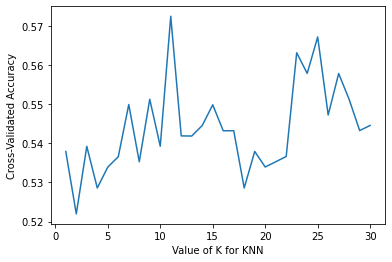

In [259]:
from sklearn.model_selection import cross_val_score
# choose k between 1 to 31
k_range = range(1, 31)
k_scores = []
# use iteration to caclulator different k in models, then return the average accuracy based on the cross validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train,train_y, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())
# plot to see clearly
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

As we can see the best K is around 11, after 13 the accuracy got decreased due to under-fitting.

In [272]:
knn_cv =KNeighborsClassifier(n_neighbors=11)

In [273]:
knn_cv.fit(x_train,train_y)

KNeighborsClassifier(n_neighbors=11)

In [274]:
pred_knn=knn_cv.predict(x_test)

In [275]:
accuracy_score(pred_knn,test_y)
print(classification_report(pred_knn,test_y))

              precision    recall  f1-score   support

         cat       0.80      0.53      0.63       186
         dog       0.31      0.62      0.41        65

    accuracy                           0.55       251
   macro avg       0.55      0.57      0.52       251
weighted avg       0.67      0.55      0.58       251



Now the accuracy is increased by 2 percent with k value as 11. Final accuracy is 55%

# Implementing Decision Tree Model

Decision tree builds classification or regression models in the form of a tree structure. It breaks down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed. The final result is a tree with decision nodes and leaf nodes.

It is implemented in sklearn using the DecisionTreeClassifier class. We begin by importing it:

In [277]:
from sklearn.tree import DecisionTreeClassifier

In [278]:
dtc=DecisionTreeClassifier()

In [279]:
dtc.fit(x_train,train_y)

DecisionTreeClassifier()

In [280]:
y_pred_dtc=dtc.predict(x_test)
y_pred_dtc

array(['cat', 'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog',
       'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat', 'dog', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'cat', 'dog',
       'dog', 'cat', 'dog', 'dog', 'dog', 'cat', 'cat', 'dog', 'dog',
       'dog', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat', 'dog', 'cat', 'dog', 'dog', 'cat', 'cat', 'dog', 'cat',
       'dog', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat', 'dog', 'cat',
       'dog', 'cat', 'dog', 'dog', 'dog', 'cat', 'dog', 'cat', 'cat',
       'dog', 'dog', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat',
       'cat', 'dog', 'dog', 'cat', 'dog', 'dog', 'cat', 'dog', 'cat',
       'dog', 'dog', 'dog', 'cat', 'dog', 'dog', 'cat', 'dog', 'dog',
       'dog', 'cat', 'dog', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat',
       'dog', 'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog',
       'cat', 'dog', 'dog', 'cat', 'dog', 'dog', 'dog', 'cat', 'dog',
       'cat', 'dog',

In [281]:
accuracy_score(y_pred_dtc,test_y)
print(classification_report(y_pred_dtc,test_y))

              precision    recall  f1-score   support

         cat       0.47      0.51      0.49       114
         dog       0.56      0.53      0.54       137

    accuracy                           0.52       251
   macro avg       0.52      0.52      0.52       251
weighted avg       0.52      0.52      0.52       251



In [282]:
confusion_matrix(y_pred_dtc,test_y)

array([[58, 56],
       [65, 72]], dtype=int64)

We got 52% accuracy with decision tree model now lets perform Cross validation.Cross validation isn't used for buliding/pruning the decision tree. It's used to estimate how good the tree (built on all of the data) lets see now.

In [284]:
cross_val_score(dtc, x_train,train_y, cv=10)

array([0.5       , 0.56      , 0.57333333, 0.46666667, 0.57333333,
       0.54666667, 0.56      , 0.52      , 0.42666667, 0.54666667])

We can see that Decison tree gives maximum of 57% accuracy.

# Implementing K-means Model

In [285]:
clusters = kmeans.fit_predict(x_train)
kmeans.cluster_centers_.shape

C:\Users\sonip\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:887: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


(2, 27648)

In [292]:
data_label = []
for i in train_y:
    if i=="cat": data_label.append(0)
    else: data_label.append(1)
data_label = np.array(data_label)

This is the standard code for k-means clustering defined in sklearn. kmeans.cluster_centers_ contains 2 centroids with 3072 sizes. These centroids may or may not lie on images from the dataset.

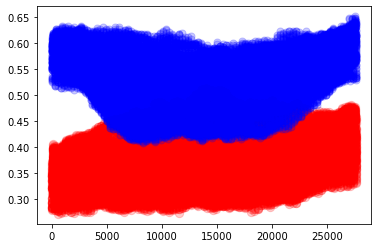

In [286]:
x_data = [i for i in range(27648)]
plt.scatter(x_data,kmeans.cluster_centers_[0], color = 'red',alpha=0.2,s=70)
plt.scatter(x_data,kmeans.cluster_centers_[1] , color = 'blue',alpha=0.2,s=50)

In the above image, we can see that some points are intersecting. This shows that K-Means will be confused while classification. The best value is where they both are completely separated. We have used the x-axis of 3072 because that is the size of our image. And plotted image value in the y-axis.

In [293]:
# mapping labels from cluster to original labels
def get_reference_dict(clusters,data_label):
    reference_label = {}
    # For loop to run through each label of cluster label
    for i in range(len(np.unique(clusters))):
        index = np.where(clusters == i,1,0)
        num = np.bincount(data_label[index==1]).argmax()
        reference_label[i] = num
    return reference_label
# Mapping predictions to original labels
def get_labels(clusters,refernce_labels):
    temp_labels = np.random.rand(len(clusters))
    for i in range(len(clusters)):
        temp_labels[i] = reference_labels[clusters[i]]
    return temp_labels

In [294]:
reference_labels = get_reference_dict(clusters,data_label)
predicted_labels = get_labels(clusters,reference_labels)
print(accuracy_score(predicted_labels,data_label))

0.5166444740346205


ELBOW METHOD

Accuracy for k = 2:  0.511318242343542
Accuracy for k = 16:  0.59254327563249
Accuracy for k = 64:  0.6284953395472703
Accuracy for k = 100:  0.644474034620506
Accuracy for k = 256:  0.7443408788282291


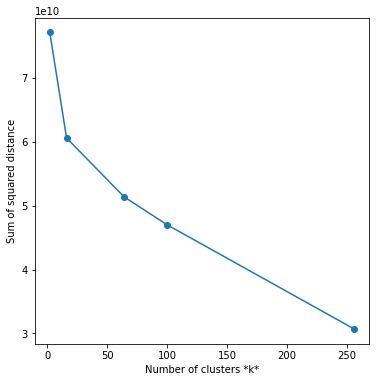

In [296]:
sse = []
list_k = [2,16,64,100,256]
for k in list_k:
    km = KMeans(n_clusters=k)
    clusters = km.fit_predict(X_train)
    sse.append(km.inertia_)
    reference_labels = get_reference_dict(clusters,data_label)
    predicted_labels = get_labels(clusters,reference_labels)
    print(f"Accuracy for k = {k}: ", accuracy_score(predicted_labels,data_label))
# Plot sse against k
plt.figure(figsize=(6, 6))
plt.plot(list_k, sse, '-o')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance');

We are we getting better accuracy at 256 instead of 2 when we know that our data contains only 2 different classes, there could be many reasons for this observation. Maybe some cats look more like dogs or maybe some cats are different from other cats. You can try an experiment to apply k-means to a dataset where you only have one breed of dog and one breed of cat. K-Means will perform pretty awesome in that case. We are getting these many clusters because there could beside photos of cats, that will surely look different from the front side. All of this is because our model doesn’t know anything about cats and dogs until we have given it the data to form clusters. It is the same as you do not know about cars and someone wants you to form clusters of cars with the same features (like the same engine power, etc).

We can further improve performance by something called Transfer learning (TL) is a research problem in machine learning (ML) that focuses on storing knowledge gained while solving one problem and applying it to a different but related problem.

# storing in data frame

In [3]:
train_df = pd.DataFrame({'image_name':os.listdir(train_path)})
train_df['label'] =train_df['image_name'].apply(lambda x: x.split('.')[0])
train_df

,image_name,label
0,cat.0.jpg,cat
1,cat.1.jpg,cat
2,cat.10.jpg,cat
3,cat.100.jpg,cat
4,cat.101.jpg,cat
...,...,...
997,dog.95.jpg,dog
998,dog.96.jpg,dog
999,dog.97.jpg,dog
1000,dog.98.jpg,dog


In [4]:
train_df["label"].value_counts()

cat    501
dog    501
Name: label, dtype: int64

# Implementing Random forest

Random forests is a supervised learning algorithm. It can be used both for classification and regression. It is also the most flexible and easy to use algorithm. A forest is comprised of trees. It is said that the more trees it has, the more robust a forest is.

Let’s build a Random Forest Classifier, For this, we must first import it from sklearn:

In [161]:
from sklearn.ensemble import RandomForestClassifier

Create an instance of the RandomForestClassifier class:

In [310]:
model=RandomForestClassifier(n_estimators=100)

Finally, let us proceed to train the model:

In [311]:
model.fit(X_train, train_y)

RandomForestClassifier()

In [313]:
y_pred=model.predict(test_X)
y_pred

array(['cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'dog', 'cat', 'cat',
       'dog', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat',
       'cat', 'dog', 'cat', 'dog', 'cat', 'dog', 'cat', 'cat', 'dog',
       'dog', 'cat', 'dog', 'cat', 'cat', 'dog', 'cat', 'dog', 'dog',
       'cat', 'dog', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'cat',
       'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'cat',
       'dog', 'dog', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat',
       'dog', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'dog', 'dog',
       'cat', 'dog', 'cat', 'dog', 'dog', 'dog', 'dog', 'cat', 'dog',
       'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'dog', 'dog', 'cat',
       'cat', 'dog', 'cat', 'cat', 'dog', 'dog', 'dog', 'cat', 'dog',
       'dog', 'cat', 'cat', 'dog', 'cat', 'dog', 'cat', 'cat', 'cat',
       'dog', 'dog', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat', 'dog',
       'dog', 'cat',

In [314]:
acc = model.score(test_X, test_y)
print("Raw pixel accuracy: {:.2f}%".format(acc * 100))

Raw pixel accuracy: 64.54%


In [ ]:
Random  forest gives accuracy of 64.54%.

In [315]:
accuracy_score(y_pred,test_y)
print(classification_report(y_pred,test_y))

              precision    recall  f1-score   support

         cat       0.70      0.62      0.66       138
         dog       0.59      0.67      0.63       113

    accuracy                           0.65       251
   macro avg       0.65      0.65      0.64       251
weighted avg       0.65      0.65      0.65       251



In [178]:
confusion_matrix(y_pred,test_y)

array([[  0,   0],
       [123, 128]], dtype=int64)

# Implementing CNN Model

CNN is a powerful algorithm for image processing. These algorithms are currently the best algorithms we have for the automated processing of images.

Convolutional Neural Networks specialized for applications in image & video recognition. CNN is mainly used in image analysis tasks like Image recognition, Object detection & Segmentation.

There are three types of layers in Convolutional Neural Networks:

1) Convolutional Layer: In a typical neural network each input neuron is connected to the next hidden layer. In CNN, only a small region of the input layer neurons connect to the neuron hidden layer.

2) Pooling Layer: The pooling layer is used to reduce the dimensionality of the feature map. There will be multiple activation & pooling layers inside the hidden layer of the CNN.

3) Fully-Connected layer: Fully Connected Layers form the last few layers in the network. The input to the fully connected layer is the output from the final Pooling or Convolutional Layer, which is flattened and then fed into the fully connected layer.

In [322]:
#splitting data for CNN
from sklearn.model_selection import train_test_split
x_train, x_val = train_test_split(train_df, test_size=0.2, random_state=2)

In [323]:
x_train.head(), x_val.head()

(      image_name label
 175  cat.256.jpg   cat
 510  dog.106.jpg   dog
 453   cat.56.jpg   cat
 374  cat.435.jpg   cat
 200  cat.279.jpg   cat,
       image_name label
 37   cat.131.jpg   cat
 398  cat.457.jpg   cat
 384  cat.444.jpg   cat
 825  dog.390.jpg   dog
 812  dog.379.jpg   dog)

In [324]:
#resetting indexes to start from 0
x_train = x_train.reset_index(drop=True)
x_val = x_val.reset_index(drop=True)

In [325]:
x_train.head(), x_val.head()

(    image_name label
 0  cat.256.jpg   cat
 1  dog.106.jpg   dog
 2   cat.56.jpg   cat
 3  cat.435.jpg   cat
 4  cat.279.jpg   cat,
     image_name label
 0  cat.131.jpg   cat
 1  cat.457.jpg   cat
 2  cat.444.jpg   cat
 3  dog.390.jpg   dog
 4  dog.379.jpg   dog)

Since there is not much of data and CNN performs best with more data we use image augmentation. The image augmentation technique is a great way to expand the size of your dataset.

Image augmentation is a technique of applying different transformations to original images which results in multiple transformed copies of the same image. Each copy, however, is different from the other in certain aspects depending on the augmentation techniques you apply like shifting, rotating, flipping, etc.

Applying these small amounts of variations on the original image does not change its target class but only provides a new perspective of capturing the object in real life. And so, we use it is quite often for building deep learning models.

It lets you augment your images in real-time while your model is still training! You can apply any random transformations on each training image as it is passed to the model. This will not only make your model robust but will also save up on the overhead memory!

Image data generators for training and validation data being prepared below with various processing being applied on images.

In [326]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255)


valid_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255)

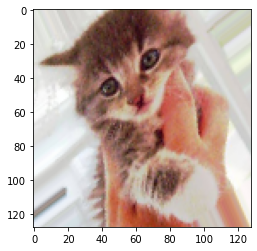

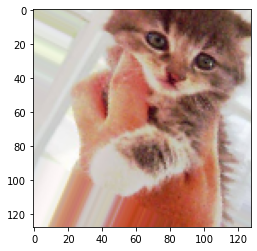

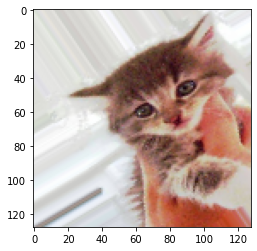

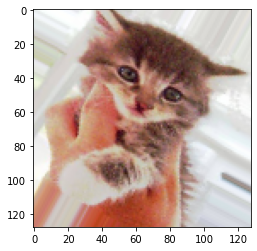

In [327]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_path, filename) for filename in os.listdir(train_path)]
img_path = fnames[3]

img = image.load_img(img_path, target_size=(128, 128))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)

i = 0
for batch in train_datagen.flow(x, batch_size=1):
 plt.figure(i)
 imgplot = plt.imshow(image.array_to_img(batch[0]))
 i += 1
 if i % 4 == 0:
        break
plt.show()

The flow_from_dataframe() method takes the Pandas DataFrame and the path to a directory and generates batches of augmented/normalized data.

In [340]:
train_generator = train_datagen.flow_from_dataframe(
    x_train,
    train_path, 
    x_col='image_name',
    y_col='label',
    target_size=(128,128),
    class_mode='categorical',
    batch_size=15
 )

valid_generator = valid_datagen.flow_from_dataframe( 
    x_val,
    train_path, 
    x_col='image_name',
    y_col='label',
    target_size=(128,128),
    class_mode='categorical',
    batch_size=15
 )

Found 801 validated image filenames belonging to 2 classes.
Found 201 validated image filenames belonging to 2 classes.


In [341]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (15, 128, 128, 3)
labels batch shape: (15, 2)


where 15 is the number of samples in each batch, 96 * 96 refers to the height and width of the image and 3 refers to the RGB.

In [342]:
for data_batch, labels_batch in valid_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (15, 128, 128, 3)
labels batch shape: (15, 2)


Let’s define the Convolutional Neural Network (CNN)

In [343]:
model = keras.models.Sequential([
                         keras.layers.Conv2D(filters=64, kernel_size=3, strides=(1,1), padding='valid',activation= 'relu', input_shape=(128,128,3)),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Conv2D(filters=128, kernel_size=3, strides=(2,2), padding='same', activation='relu'),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2,2), padding='same', activation='relu'),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Flatten(),
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dropout(0.25),
                         keras.layers.Dense(units=256, activation='relu'),
                         keras.layers.Dropout(0.5),
                         keras.layers.Dense(units=256, activation='relu'),
                         keras.layers.Dropout(0.25),                        
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dropout(0.10),                         
                         keras.layers.Dense(units=2, activation='softmax')
])

Let's display the architecture of our model so far:

In [344]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 126, 126, 64)      1792      
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 63, 63, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 16, 16, 128)      0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 8, 8, 64)          73792     
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 4, 4, 64)        

Compiling our CNN model

In [345]:
model.compile(loss='categorical_crossentropy',
 optimizer="adam",
 metrics=['accuracy'])

Training model

In [346]:
history = model.fit(train_generator, epochs=100, verbose=1, validation_data=valid_generator)

Epoch 1/100
54/54 [==============================] - 21s 362ms/step - loss: 0.6968 - accuracy: 0.4994 - val_loss: 0.6928 - val_accuracy: 0.5075
Epoch 2/100
54/54 [==============================] - 18s 328ms/step - loss: 0.6943 - accuracy: 0.4956 - val_loss: 0.6950 - val_accuracy: 0.4925
Epoch 3/100
54/54 [==============================] - 18s 337ms/step - loss: 0.6943 - accuracy: 0.4919 - val_loss: 0.6931 - val_accuracy: 0.4925
Epoch 4/100
54/54 [==============================] - 17s 322ms/step - loss: 0.6936 - accuracy: 0.5119 - val_loss: 0.6941 - val_accuracy: 0.4925
Epoch 5/100
54/54 [==============================] - 18s 326ms/step - loss: 0.6975 - accuracy: 0.4981 - val_loss: 0.6934 - val_accuracy: 0.4925
Epoch 6/100
54/54 [==============================] - 18s 335ms/step - loss: 0.6936 - accuracy: 0.4844 - val_loss: 0.6932 - val_accuracy: 0.4677
Epoch 7/100
54/54 [==============================] - 18s 336ms/step - loss: 0.6942 - accuracy: 0.5044 - val_loss: 0.6930 - val_accuracy:

Evaluating Model

In [347]:
score, acc = model.evaluate(valid_generator,batch_size=64)                       
print('Test score:', score)
print('Test accuracy:', acc)

14/14 [==============================] - 1s 87ms/step - loss: 0.6216 - accuracy: 0.7313
Test score: 0.6215668320655823
Test accuracy: 0.7313432693481445


In [90]:
cnn_prediction = model.predict(valid_generator)
cnn_prediction

array([[0.4037461 , 0.59625393],
       [0.6933708 , 0.3066292 ],
       [0.48667303, 0.51332694],
       [0.6733923 , 0.32660767],
       [0.34374815, 0.6562519 ],
       [0.8600441 , 0.13995588],
       [0.48076922, 0.51923084],
       [0.5654804 , 0.43451965],
       [0.72735876, 0.27264124],
       [0.78940654, 0.21059342],
       [0.17724954, 0.82275045],
       [0.4333403 , 0.5666597 ],
       [0.5446523 , 0.45534772],
       [0.42826107, 0.57173896],
       [0.43202177, 0.56797826],
       [0.4676388 , 0.53236127],
       [0.48811457, 0.51188546],
       [0.2496804 , 0.75031966],
       [0.4127637 , 0.5872363 ],
       [0.5403793 , 0.45962074],
       [0.48459768, 0.5154023 ],
       [0.64064467, 0.3593553 ],
       [0.62788993, 0.37211013],
       [0.81571764, 0.18428232],
       [0.60647607, 0.39352402],
       [0.53315663, 0.46684337],
       [0.6656966 , 0.33430344],
       [0.63958925, 0.36041078],
       [0.5244497 , 0.47555026],
       [0.02699705, 0.973003  ],
       [0.

In [42]:
model.save('cats_and_dogs_2.h5')

In [91]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

Plotting training and validation accuracy and los graphs.

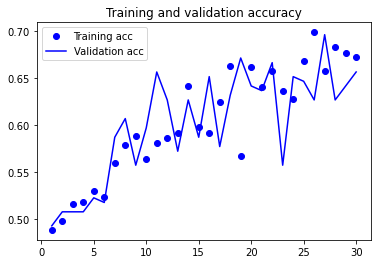

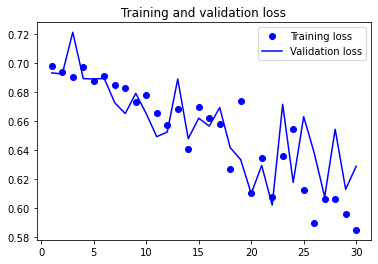

In [92]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
CNN gives us the highest accuracy so far.

# Conclusion

So far in this report we explored how to use image classification for classifying an image as Dog or Cat in Machine Learning by implementing common ML algorithms and one deep learning algorithm including Decision Tree, Random Forest, KNN, K-Means, and CNN. K means Classifier shows the best performance with 74% accuracy followed by CNN with 73% accuracy, Random Forest with 64.5% accuracy, Decision Tree with 57% accuracy and KNN with 55% accuracy. Thus, K Means exhibits the best performance and KNN the worst.